In [ ]:
!pip install transformers datasets Pillow torch torchvision -q

In [ ]:
import os
import json
import torch
import numpy as np
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torch.optim import AdamW
from transformers import get_scheduler, BlipProcessor, BlipForQuestionAnswering
from torch.cuda.amp import GradScaler, autocast
from datasets import load_dataset
from tqdm import tqdm

In [ ]:
CONFIG = {
    "model_name":    "Salesforce/blip-vqa-base",
    "train_samples": 5000,
    "val_samples":   1000,
    "test_samples":  1000,
    "batch_size":    8,        # safe for T4 16GB with fp16
    "epochs":        3,
    "lr":            3e-5,
    "weight_decay":  0.01,      # AdamW regularization
    "warmup_ratio":  0.1,       # 10% of steps for warmup
    "max_length":    32,        # max tokens for question
    "save_path":     "./blip_vqa_finetuned",
}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

Using device: cuda
GPU: Tesla T4
VRAM: 15.6 GB


In [ ]:
from torch.utils.data import IterableDataset

class VQADataset(IterableDataset):
    def __init__(self, hf_data, processor, max_length=32):
        self.data       = hf_data
        self.processor  = processor
        self.max_length = max_length

    def __iter__(self):
        for item in self.data:
            image    = item["image"].convert("RGB")
            question = item["question"]
            answer   = item["multiple_choice_answer"]

            encoding = self.processor(
                images         = image,
                text           = question,
                return_tensors = "pt",
                padding        = "max_length",
                truncation     = True,
                max_length     = self.max_length,
            )

            label_encoding = self.processor.tokenizer(
                answer,
                return_tensors = "pt",
                padding        = "max_length",
                truncation     = True,
                max_length     = 10,
            )

            yield {
                "input_ids":      encoding["input_ids"].squeeze(),
                "attention_mask": encoding["attention_mask"].squeeze(),
                "pixel_values":   encoding["pixel_values"].squeeze(),
                "labels":         label_encoding["input_ids"].squeeze(),
            }

In [ ]:
from datasets import load_dataset

raw = load_dataset(
    "lmms-lab/vqav2",
    split="validation",
    streaming=True
)

raw = raw.shuffle(seed=42)

# take total subset first
raw = raw.take(7000)

# split manually
train_size = CONFIG["train_samples"]

train_ds = raw.take(CONFIG["train_samples"])
val_ds   = raw.skip(CONFIG["train_samples"]).take(CONFIG["val_samples"])
test_ds  = raw.skip(CONFIG["train_samples"] + CONFIG["val_samples"]).take(CONFIG["test_samples"])

Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/143 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/68 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/36 [00:00<?, ?it/s]

Resolving data files:   0%|          | 0/143 [00:00<?, ?it/s]

In [ ]:
from transformers import BlipProcessor, BlipForQuestionAnswering

processor = BlipProcessor.from_pretrained("Salesforce/blip-vqa-base")
model = BlipForQuestionAnswering.from_pretrained(
    "Salesforce/blip-vqa-base",
    torch_dtype = torch.bfloat16,
)
model.to(DEVICE)

preprocessor_config.json:   0%|          | 0.00/445 [00:00<?, ?B/s]

The image processor of type `BlipImageProcessor` is now loaded as a fast processor by default, even if the model checkpoint was saved with a slow processor. This is a breaking change and may produce slightly different outputs. To continue using the slow processor, instantiate this class with `use_fast=False`. 


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/592 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/1.54G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning
BlipForQuestionAnswering LOAD REPORT from: Salesforce/blip-vqa-base
Key                                       | Status     |  | 
------------------------------------------+------------+--+-
text_encoder.embeddings.position_ids      | UNEXPECTED |  | 
text_decoder.bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


BlipForQuestionAnswering(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-05, e

In [ ]:
train_dataset = VQADataset(train_ds, processor)
val_dataset   = VQADataset(val_ds,   processor)

train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], num_workers=0)
val_loader   = DataLoader(val_dataset,   batch_size=CONFIG["batch_size"], num_workers=0)

In [ ]:
optimizer = AdamW(
    model.parameters(),
    lr           = CONFIG["lr"],
    weight_decay = CONFIG["weight_decay"],
    eps          = 1e-8,
)

scaler = GradScaler()

print("Ready to train")

Ready to train


/tmp/ipykernel_10964/2186000890.py:8: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()


In [ ]:
from transformers import get_linear_schedule_with_warmup

total_steps  = (CONFIG["train_samples"] // CONFIG["batch_size"]) * CONFIG["epochs"]
warmup_steps = int(total_steps * CONFIG["warmup_ratio"])

scheduler = get_linear_schedule_with_warmup(
    optimizer,
    num_warmup_steps   = warmup_steps,
    num_training_steps = total_steps,
)

print(f"Total steps  : {total_steps}")
print(f"Warmup steps : {warmup_steps}")

Total steps  : 1875
Warmup steps : 187


In [ ]:
def exact_match(pred, true):
    return 1.0 if pred.strip().lower() == true.strip().lower() else 0.0

def vqa_accuracy(pred, answers):
    pred = pred.strip().lower()
    count = sum(1 for a in answers if a["answer"].strip().lower() == pred)
    return min(count / 3.0, 1.0)

In [ ]:
best_val_loss = float("inf")

for epoch in range(CONFIG["epochs"]):

    # ── Training ──────────────────────────────────────────
    model.train()
    train_loss  = 0
    train_em    = 0
    step_count  = 0
    train_iter  = iter(train_ds)  # for getting raw answers
    progress    = tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']}")

    for batch in progress:
        input_ids      = batch["input_ids"].to(DEVICE)
        attention_mask = batch["attention_mask"].to(DEVICE)
        pixel_values   = batch["pixel_values"].to(DEVICE)
        labels         = batch["labels"].to(DEVICE)

        optimizer.zero_grad()

        with torch.amp.autocast("cuda"):
            outputs = model(
                input_ids      = input_ids,
                attention_mask = attention_mask,
                pixel_values   = pixel_values,
                labels         = labels,
            )
            loss = outputs.loss

        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()

        # exact match on this batch
        with torch.no_grad():
            generated = model.generate(
                input_ids    = input_ids,
                pixel_values = pixel_values,
                max_new_tokens = 10,
            )
        preds = processor.batch_decode(generated, skip_special_tokens=True)

        for j in range(len(preds)):
            raw_sample  = next(train_iter)
            true_answer = raw_sample["multiple_choice_answer"]
            train_em   += exact_match(preds[j], true_answer)

        train_loss += loss.item()
        step_count += 1
        progress.set_postfix(loss=f"{train_loss/step_count:.4f}")

    train_loss = train_loss / step_count
    train_em   = train_em  / (step_count * CONFIG["batch_size"])

    # ── Validation ────────────────────────────────────────
    model.eval()
    val_loss    = 0
    val_em      = 0
    val_vqa     = 0
    val_steps   = 0
    val_iter    = iter(val_ds)

    with torch.no_grad():
        for batch in tqdm(val_loader, desc="Validating"):
            input_ids      = batch["input_ids"].to(DEVICE)
            attention_mask = batch["attention_mask"].to(DEVICE)
            pixel_values   = batch["pixel_values"].to(DEVICE)
            labels         = batch["labels"].to(DEVICE)

            with torch.amp.autocast("cuda"):
                outputs = model(
                    input_ids      = input_ids,
                    attention_mask = attention_mask,
                    pixel_values   = pixel_values,
                    labels         = labels,
                )
            val_loss += outputs.loss.item()

            generated = model.generate(
                input_ids      = input_ids,
                pixel_values   = pixel_values,
                max_new_tokens = 10,
            )
            preds = processor.batch_decode(generated, skip_special_tokens=True)

            for j in range(len(preds)):
                raw_sample  = next(val_iter)
                true_answer = raw_sample["multiple_choice_answer"]
                all_answers = raw_sample["answers"]
                val_em     += exact_match(preds[j], true_answer)
                val_vqa    += vqa_accuracy(preds[j], all_answers)

            val_steps += 1

    val_loss = val_loss / val_steps
    val_em   = val_em  / (val_steps * CONFIG["batch_size"])
    val_vqa  = val_vqa / (val_steps * CONFIG["batch_size"])

    print(f"\nEpoch {epoch+1} Results:")
    print(f"  Train — loss: {train_loss:.4f} | exact match: {train_em*100:.1f}%")
    print(f"  Val   — loss: {val_loss:.4f} | exact match: {val_em*100:.1f}% | VQA acc: {val_vqa*100:.1f}%")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        model.save_pretrained(CONFIG["save_path"])
        processor.save_pretrained(CONFIG["save_path"])
        print(f"  ✓ Best model saved")

print("\nTraining complete!")

Epoch 1/3: 0it [00:00, ?it/s]We strongly recommend passing in an `attention_mask` since your input_ids may be padded. See https://huggingface.co/docs/transformers/troubleshooting#incorrect-output-when-padding-tokens-arent-masked.
Epoch 1/3: 625it [13:11,  1.27s/it, loss=5.0420]
Validating: 125it [01:58,  1.05it/s]


Epoch 1 Results:
  Train — loss: 5.0420 | exact match: 13.4%
  Val   — loss: 0.1592 | exact match: 11.1% | VQA acc: 13.3%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved


Epoch 2/3: 0it [00:00, ?it/s]'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/lmms-lab/vqav2/resolve/32665d35052eb4a6d4414851c3c829a72754915a/data/validation-00021-of-00068.parquet
Retrying in 1s [Retry 1/5].
Epoch 2/3: 6it [00:21,  2.07s/it, loss=0.1400]'The read operation timed out' thrown while requesting GET https://huggingface.co/datasets/lmms-lab/vqav2/resolve/32665d35052eb4a6d4414851c3c829a72754915a/data/validation-00021-of-00068.parquet
Retrying in 1s [Retry 1/5].
Epoch 2/3: 625it [13:14,  1.27s/it, loss=0.0934]
Validating: 125it [01:56,  1.07it/s]


Epoch 2 Results:
  Train — loss: 0.0934 | exact match: 19.6%
  Val   — loss: 0.1215 | exact match: 14.8% | VQA acc: 17.6%


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ Best model saved


Epoch 3/3: 625it [13:01,  1.25s/it, loss=0.0523]
Validating: 125it [01:56,  1.08it/s]


Epoch 3 Results:
  Train — loss: 0.0523 | exact match: 17.5%
  Val   — loss: 0.1233 | exact match: 14.7% | VQA acc: 17.5%

Training complete!


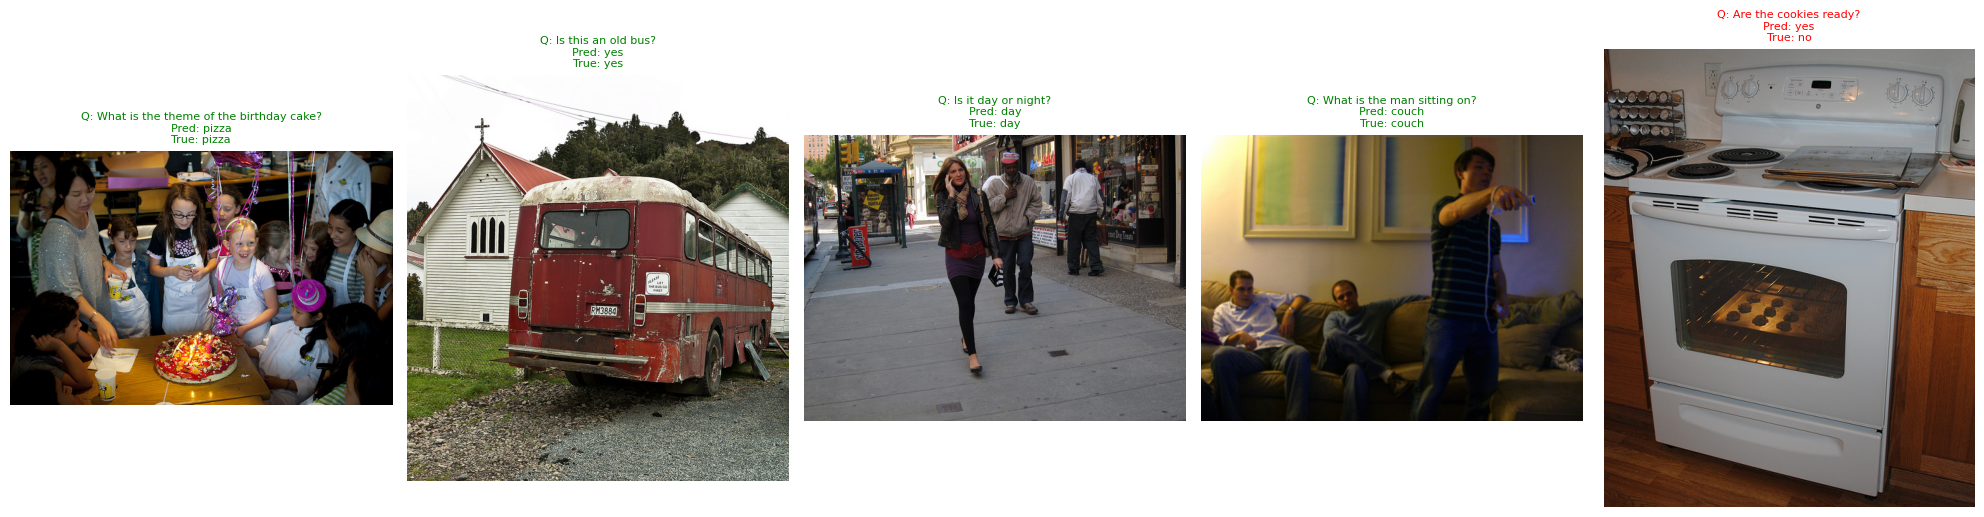

Done!


In [ ]:
import matplotlib.pyplot as plt

model.eval()
val_iter = iter(val_ds)

fig, axes = plt.subplots(1, 5, figsize=(20, 5))

for i in range(5):
    sample   = next(val_iter)
    image    = sample["image"].convert("RGB")
    question = sample["question"]
    correct  = sample["multiple_choice_answer"]

    inputs = processor(
        images         = image,
        text           = question,
        return_tensors = "pt",
    ).to(DEVICE)

    with torch.no_grad():
        output = model.generate(**inputs, max_new_tokens=10)

    answer = processor.decode(output[0], skip_special_tokens=True)

    axes[i].imshow(image)
    axes[i].axis("off")
    color = "green" if answer.strip().lower() == correct.strip().lower() else "red"
    axes[i].set_title(f"Q: {question}\nPred: {answer}\nTrue: {correct}",
                      fontsize=8, color=color)

plt.tight_layout()
plt.savefig("visual_test.png", dpi=150, bbox_inches="tight")
plt.show()
print("Done!")

In [ ]:
model.save_pretrained(CONFIG["save_path"])
processor.save_pretrained(CONFIG["save_path"])
print("Model saved!")

In [ ]:
import shutil
shutil.make_archive("blip_vqa_finetuned", "zip", CONFIG["save_path"])
print("Zipped!")

Zipped!


In [ ]:
from google.colab import files
files.download("blip_vqa_finetuned.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import shutil
shutil.unpack_archive("/content/drive/MyDrive/blip_vqa_finetuned.zip", "/content/blip_vqa_finetuned")

In [ ]:
processor = BlipProcessor.from_pretrained("/content/blip_vqa_finetuned")
model     = BlipForQuestionAnswering.from_pretrained(
    "/content/blip_vqa_finetuned",
    torch_dtype = torch.bfloat16,
)
model.to(DEVICE)

Loading weights:   0%|          | 0/788 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie text_decoder.bert.embeddings.word_embeddings.weight to text_decoder.cls.predictions.decoder.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


BlipForQuestionAnswering(
  (vision_model): BlipVisionModel(
    (embeddings): BlipVisionEmbeddings(
      (patch_embedding): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
    )
    (encoder): BlipEncoder(
      (layers): ModuleList(
        (0-11): 12 x BlipEncoderLayer(
          (self_attn): BlipAttention(
            (dropout): Dropout(p=0.0, inplace=False)
            (qkv): Linear(in_features=768, out_features=2304, bias=True)
            (projection): Linear(in_features=768, out_features=768, bias=True)
          )
          (layer_norm1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): BlipMLP(
            (activation_fn): GELUActivation()
            (fc1): Linear(in_features=768, out_features=3072, bias=True)
            (fc2): Linear(in_features=3072, out_features=768, bias=True)
          )
          (layer_norm2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
        )
      )
    )
    (post_layernorm): LayerNorm((768,), eps=1e-05, e

In [ ]:
def exact_match(pred, true):
    return 1.0 if pred.strip().lower() == true.strip().lower() else 0.0

def vqa_accuracy(pred, answers):
    pred = pred.strip().lower()
    count = sum(1 for a in answers if a["answer"].strip().lower() == pred)
    return min(count / 3.0, 1.0)

In [ ]:
model.eval()
test_em   = 0
test_vqa  = 0
total     = 0

with torch.no_grad():
    for sample in tqdm(test_ds, desc="Testing"):
        image    = sample["image"].convert("RGB")
        question = sample["question"]
        true_answer = sample["multiple_choice_answer"]
        all_answers = sample["answers"]

        inputs = processor(
            images         = image,
            text           = question,
            return_tensors = "pt",
        ).to(DEVICE)

        with torch.amp.autocast("cuda"):
            output = model.generate(**inputs, max_new_tokens=10)

        pred = processor.decode(output[0], skip_special_tokens=True)

        test_em  += exact_match(pred, true_answer)
        test_vqa += vqa_accuracy(pred, all_answers)
        total    += 1

print(f"\nTest Results ({total} samples):")
print(f"  Exact Match  : {test_em/total*100:.1f}%")
print(f"  VQA Accuracy : {test_vqa/total*100:.1f}%")

Testing: 1000it [02:03,  8.08it/s]


Test Results (1000 samples):
  Exact Match  : 76.1%
  VQA Accuracy : 84.8%
